**6장 - 결정 트리**

**결정 트리(decision tree)** 는 분류와 회귀 작업 그리고 다중 출력 작업까지 가능한 다목적 머신러닝 알고리즘임. 또한 매우 복접한 데이터셋도 학습할 수 있는 알고리즘임.

# 설정

이 프로젝트를 실행하려면 파이썬 3.7 이상이 필요함:

In [2]:
import sys

assert sys.version_info >= (3, 7)

또한 사이킷런 1.0.1 이상이 필요함:

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

기본 글꼴 크기를 정의함:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

이미지를 저장할 경로와 함수를 정의함:

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_tree"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [6]:
from sklearn import set_config

set_config(display="text")

## 결정 트리 학습과 시각화

결정 트리를 이해하기 위해 모델 하나를 만들어 어떻게 예측을 하는지 확인.

DecisionTreeClassifier :

In [7]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

export_graphviz() 함수를 이용해 그래프 정의를 iris_tree.dot파일로 출력하여 훈련된 결정 트리르 시각화 할 수 있음.

In [8]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file=str(IMAGES_PATH / "iris_tree.dot"),
    feature_names=["petal length(cm)", "petal width(cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

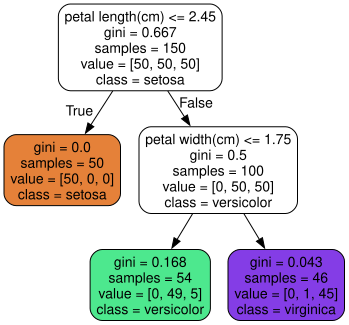

In [9]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")

Graphviz는 `.dot` 파일을 다양한 포맷으로 변환할 수 있는 'dot' 명령줄 도구도 제공함.

다음 명령어는 dot파일을 png 이미지로 변환

In [10]:
!dot -Tpng {IMAGES_PATH / "iris_tree.dot"} -o {IMAGES_PATH / "iris_tree.png"}

## 예측

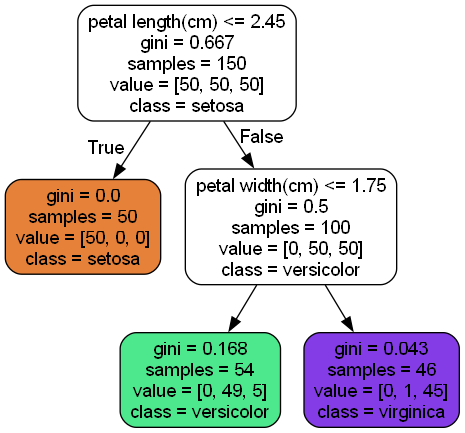

해당 트리가 어떻게 예측을 만들어냈는 방법.

꽃잎을 기준으로 하여 새로 발견하 붓꽃의 품종를 분류하려 한다고 가정하겠음.

1. **루트 노드(root node)** 에서 시작함. 이 노드는 꽃잎의 길이가 2.45cm보다 짧은지 검사함. 
2. 만약 그렇다면 루트 노드에서 왼쪽 자식 노드(child node)로 이동. 이 경우 이 노드가 **리프 노드(leaf node)** 이므로 추가적인 검사를 하지않음 그냥 노드에 있는 예측 클래스를 보고 결정 트리가 새로 바견한 꽃의 품종을 Iris-Setosa(class=setosa)라고 예측함.

또 다른 꽃을 발견했는데 이번엔 길이가 2.45보다 긺.
1. 다시 루트 노드에서 시작하지만 오른쪽 자식노드로 이동함. 
2. 추가로 '꽃잎의 너비가 1.75cm보다 작은지` 검사함.
3. 만약 그렇다면 Iris-Versicolor, 아니라면 Iris-Virginica

노드의 sample 속성은 얼마나 많은 훈련 샘플이 적용되었느지 헤아리는 것.

- 예) 100개의 훔련 샘플의 꽃잎 길이가 2.45cm 보다 길고, 그중 54개 샘플의 꽃ㅊ잎 너비가 1.75cm보다 짧음

노드의 value 속성은 노드에서 각 클래스에 얼마나 많은 훈련 샘플이 있는 알려줌.

- 예) 오른쪽 아래 노드는 Iris-Setosa가 0개이고, Iris-Versicolo가 1개, Iris-Virginica가 45개 였음

노드의 gini속성은 **지니 불순도(gini impurity)** 를 측정함. 한 노드의 모든 샘플이 같은 클래스에 속해 있다면 노드의 순수(gini=0)하다고 말함

- 예) 1의 왼쪽 노드는 Iris-Setosa 훈련 샘플만 가지고 있으므로 순수 노드이고 지니 불손도가 0임.

아래의 식은 훈련 알고리즘이 $i$번째 노드의 지니 불순도 $G_i$를 계산하는 방법을 보여줌.
깊이 2의 왼쪽 노드의 지니 불순도는 $1-(0 / 54)^2-(49/54)^2-(5/54)^2 \approx(0.168) $

지니 불순도 : 
$$
G_i = 1 - \sum_{k=1}^{n} (p_{i,k})^2
$$


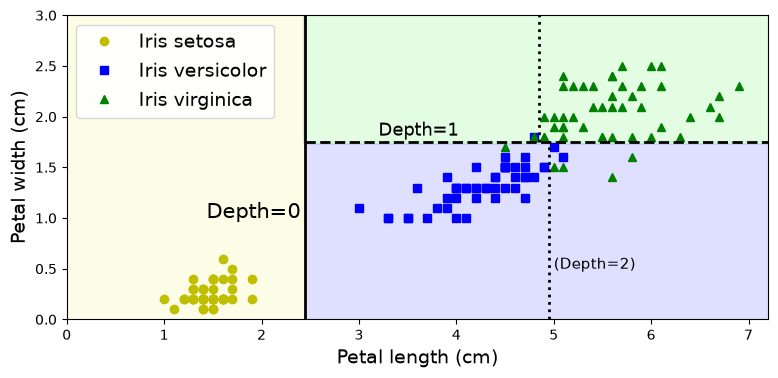

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_decision_boundaries_plot")

plt.show()

트리 구조는 `tree_` 속성을 통해 엑세스 가능

In [12]:
tree_clf.tree_

# 자세한 내용은 아래의 클래스 문서 참조
# help(sklearn.tree._tree.Tree)

## 클래스 확률 추정

결정 트리는 한 샘플임 특정 클래스 $k$에 속할 확률을 추정 할 수도 있음. 먼저 이 샘플이 리프 노드를 찾기 위해 트리를 탐색하고 그 노드에 있는 클래스 $k$의 훌련 샘플의 비율을 반환함.

예) 길이가 5cm이고 너비가 1.5cm인 꽃잎을 발견해싸고 가정. 이에 해당하는 리프 노드는 깊이 2에서 왼쪽 노드 이므로 결정 트리는 그에 해당하는 확률 을 출력함.

Iris-Setosa는 0%, Iris-Versicolor 는90.7%, Iris-Virginica는 9.3%임.만약 클래스를 하나 예측한다면 가장 높은 확률을 가진 Iris-Versicolor를 출력할 것임

In [13]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [14]:
tree_clf.predict([[5, 1.5]])

array([1])

## CART 훈련 알고리즘

사이킷런은 결정 트리를 훈련시키기 위해 **CART(classification and regression tree)** 알고리즘을 사용함.

먼저 훈련 세트를 하나의 특성 $k$의 임계값 $t_k$를 사용해 두개의 서브셋으로 나눔. 

$k$와 $t_k$를 나누는 법은. 크기에 따라 가중치가 적용된 가장 단순한 서브셋으로 나눌수 있는 $(k , t_K)$ 쌍을 찾음. 

이 알고리즘이 최소화 해야하는 비용함수. 

분류에 대한 CART 비용함수:
$$
J(k, t_k)= \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right}
$$
$$
여기서
\begin{cases} 
G_{\text{left/right}} & \text{: 왼쪽/오른쪽 서브셋의 불순도} \\ 
m_{\text{left/right}} & \text{: 왼쪽/오른쪽 서브셋의 샘플 수} 
\end{cases}
$$

CART 알고리즘이 훈련 세트를 성공적으로 둘로 나누었다면 같은 방식으로 서브셋을 또 나누고 그 다음엔 서브셋의 서브셋을 나누고 이런식으로 반복하게 됨. 

이 과정은 최대 깊이가 되거나 불순도를 줄이는 분할을 찾을 수 없을 떄 멈추게 됨.

## 계산 복잡도

예측을 하려면 결정 트리르 룰트 노드에서부터 리프 노드까지 탐색해야함. 일반적으로 약 $O(\log_2(m))$개의 노드를 거쳐야함. 각 노드는 하나의 특성값만 확인하기 떄문에 예측에 픽요한 전체 복잡도는 특성 수와 무관하게 $O(\log_2(m))$임. 

## 지니 불손도 또는 엔트로피?

기본적으로 DecisionTreeClassifier 클래슨느 지니 불순도르 ㄹ사용하지만 criterion 매개변수를 "entropy"로 지정하여 **엔트로피** 불순도를 사용할 수 있음.

엔트로피는 분자의 무질서함을 측정하는 것으로 우너래 열역학의 개념임. 분자가 안정화되고질서정연하면 엔트로피가 0에 가까움

엔트로피 예) 메시지의 펴균 정보량을 측정하는 섄넌의 정보이론. 여기서는 모든 메시지가 동일할 때 엔트로피가 0임.

머신러닝에서의 엔트로피 예) 어떤 세트가 한 클래스의 샘플만 담고 있다면 엔트로피가 0임. 아래의 식에서 $i$번째 노드의 엔트로피를 보여주고 있음

엔트로피:
$$
H_i = \underset{P_{i,k} \neq 0}{\sum_{k=1}^{n}}p_{i, k} \log_2(p_{i_k}) 
\\
$$

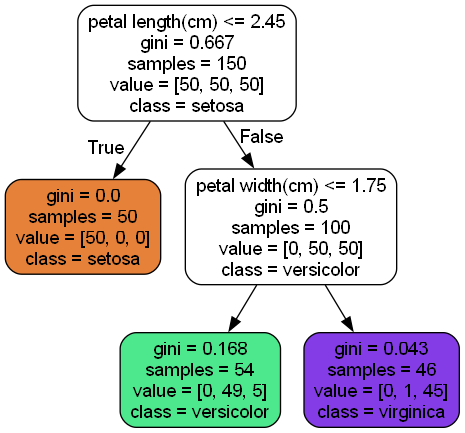

해당 그림에서의 깊이 2의 왼쪽 노드의 엔트로피는
 $-{\frac{49}{54} \log_2(\frac{49}{54})} -{\frac{5}{54} \log_2(\frac{5}{54})} \approx 0.445$임.

지니불손도와 엔트로피는 실제로 큰 차이는 없음. 둘다 비슷한 트리를 만드러냄. 

지니 불손도가 조금 더 계산이 빠르기 때문에 기본값으로 좋음. 그러나 다른 트리가 만들어지는 경우 지니 불손도는 가장 빈도 높은 클래스르 한쪽 가지(branch)로 고립시키는 경향이 있는 반면 엔트로피는 조금 더 균형 잡힌 트리를 만들어냄.

## 규제 매개변수

경정 트리는 훈련 데이터에 대한 제약 사항이 거의 없음. 제한을 두지 않으면 트리가 훈련 데이터에 아주 가깝게 맞추려고 해서 과대적합되기 쉬움. 

결정 트리는모델 파라미터가 전혀 없는 것이 아님(보통은 많음). 훈련되기 전에 파라미터 수가 결정되지 않기 때문에 **비파라미터 모델(nonparametirc model)** 이라고 함. 

반대로 선형 모델은 같은 **파라미터 모델(parametric model)** 은 모델 파라미터 수가 미리 정해져 있으므로 자유도가 제한되어 과대적합될 위험이 줄어듦.(하지만 과서적합 위험)

규제 매개변수를 사용하는 알고리즘에 따라 다르미나 보통 적어도 결정트리의 최대 깊이는 제어 할 수 있음.

사이킷런에서는 max_depth 매개변수로 이르 조절함. 기본값은 제한이 없는 것을 의미하는 것이 아닌 None임. 해당 매개 변수를 줄이면 모델을 규제하기 되고 과대적합 위험이 낮아짐.

DecisionTreeClassifier에는 비슷하게 결정 트리의 형태를 제한하는 다른 하이퍼파라미터가 몇ㅊ 개 있음.
 - max_features : 각 노드에서 분할에 사용할 특성의 최대 수
 - max_leaf_nodes : 리프 노드의 최대 수
 - min_samples_split : 분할되기 위해 노드가 가져야 하는 최소 샘플 수 
 - min_samples_leaf : 리프 노드가 생성되기 위해 가지고 있어야 할 최소 샘플 수
 - min_weight_fraction_leaf : min_samples_leaf와 같지만 가중치가 부여된 전체 샘플 수에서의 비율

min_으로 시작하는 매개변수를 증가시키거나 max_로 시작하는 매개변수를 감소시키면 모델에 규제가 커짐


mooons 데이터셋에서 규제 테스트. 규제 없는 결정트리 하나를 훈련하고 min_samples_leaf = 5로 바꾸어 다른 결정트리 훈련

In [17]:
from sklearn.datasets import  make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(random_state=42, min_samples_leaf=5)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

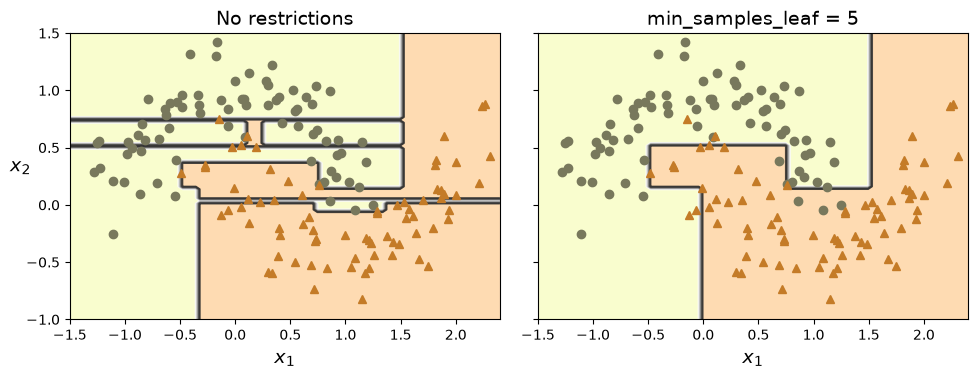

In [18]:
def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
save_fig("min_samples_leaf_plot")
plt.show()

규제가 없는 왼쪽 모델이 과대적합이며 규제를 추가한 오른쪽 모델이 일반화가 더 잘될 것임.

In [19]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43)
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [20]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

실제로 테스트 세트에서 두 번쨰 결정 트리의 정확도가 더 높음.